<a href="https://colab.research.google.com/github/mr-zero-000/Statistical-Learning-e23034/blob/main/Assignment_1%20/%20Assignment_1_Q_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bertrand's Paradox

Bertrand's Paradox illustrates that when a problem involves randomness or probability, the method used to define the 'random choice' is crucial and can lead to different results. The problem asks:

**A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?**

We will explore three different, but equally 'natural', ways to define a 'random chord' and show that they lead to different probabilities.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Define the radius of the circle for visualization
R = 1 # We can set the radius to 1 for simplicity

# Side length of an inscribed equilateral triangle
# The side length 's' of an equilateral triangle inscribed in a circle of radius 'R' is R * sqrt(3)
s = R * np.sqrt(3)

# For a chord to be longer than 's', its perpendicular distance 'd' from the center must be less than R/2.
# This is because a chord of length 's' has a perpendicular distance of R/2 from the center.
# (Using Pythagorean theorem: (s/2)^2 + d^2 = R^2 => (R*sqrt(3)/2)^2 + d^2 = R^2 => 3R^2/4 + d^2 = R^2 => d^2 = R^2/4 => d = R/2)

print(f"Circle Radius (R): {R}")
print(f"Side length of inscribed equilateral triangle (s): {s:.4f}")

Circle Radius (R): 1
Side length of inscribed equilateral triangle (s): 1.7321


### Method 1: Random Endpoints

Choose two random points on the circumference of the circle and draw the chord connecting them. For this method, fix one endpoint (due to rotational symmetry) and then randomly choose the second endpoint on the circumference.

To determine if the chord length exceeds the side length 's' of the inscribed equilateral triangle: if fix one point, the second point must fall within a specific arc for the chord to be longer than 's'. The central angle subtended by a chord of length 's' is $2\pi/3$ (120 degrees). For the chord to be longer than 's', the second point must be chosen such that the angle formed between the two endpoints is greater than $2\pi/3$ and less than $4\pi/3$ (relative to the fixed point). This 'favorable' arc length is $2\pi/3$ out of the total circumference of $2\pi$.

Probability (Method 1 - Random Endpoints): 0.3342


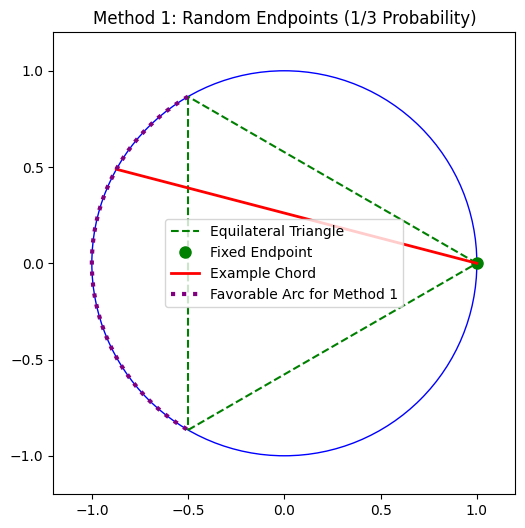

In [6]:
num_simulations = 100000
count_longer_m1 = 0

for _ in range(num_simulations):
    # For this method, we can fix one endpoint at an arbitrary position (e.g., angle 0)
    # and then choose the second point randomly along the circumference.
    # Due to rotational symmetry, the starting point of the first endpoint doesn't affect the probability.

    # Choose the angle for the second endpoint (theta2) uniformly from 0 to 2*pi
    theta2 = np.random.uniform(0, 2 * np.pi)

    # A chord of length 's' (side of an inscribed equilateral triangle) subtends a central angle of 2*pi/3 (120 degrees).
    # The length of a chord formed by points at angles 0 and theta2 is l = 2R * sin(theta2 / 2).
    # We need l > s, where s = R * np.sqrt(3).
    # So, 2R * sin(theta2 / 2) > R * np.sqrt(3)
    # sin(theta2 / 2) > np.sqrt(3) / 2

    # For theta2 in [0, 2*pi], theta2/2 is in [0, pi].
    # In the range [0, pi], sin(x) > sqrt(3)/2 implies x is in the interval (pi/3, 2*pi/3).
    # Therefore, theta2/2 must be in (pi/3, 2*pi/3).
    # This means theta2 must be in (2*pi/3, 4*pi/3).
    # This range has a length of (4*pi/3 - 2*pi/3) = 2*pi/3.
    # The total range for theta2 is 2*pi.
    # So, the probability is (2*pi/3) / (2*pi) = 1/3.

    if (theta2 > (2 * np.pi / 3)) and (theta2 < (4 * np.pi / 3)):
        count_longer_m1 += 1

probability_m1 = count_longer_m1 / num_simulations
print(f"Probability (Method 1 - Random Endpoints): {probability_m1:.4f}")

# Visualization for Method 1
fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), R, color='blue', fill=False)
ax.add_artist(circle)

# Draw an inscribed equilateral triangle
angles_triangle = [0, 2 * np.pi / 3, 4 * np.pi / 3]
for i in range(3):
    x1 = R * np.cos(angles_triangle[i])
    y1 = R * np.sin(angles_triangle[i])
    x2 = R * np.cos(angles_triangle[(i + 1) % 3])
    y2 = R * np.sin(angles_triangle[(i + 1) % 3])
    ax.plot([x1, x2], [y1, y2], color='green', linestyle='--', label='Equilateral Triangle' if i == 0 else '')

# Illustrate a 'random' chord using the corrected method: fixed point and random second point
# Fix one endpoint at (R, 0)
x_fixed = R
y_fixed = 0
ax.plot(x_fixed, y_fixed, 'go', markersize=8, label='Fixed Endpoint')

# Choose a random second point (for visualization)
theta_example_2_viz = np.random.uniform(0, 2 * np.pi)
x_c1_2_viz = R * np.cos(theta_example_2_viz)
y_c1_2_viz = R * np.sin(theta_example_2_viz)
ax.plot([x_fixed, x_c1_2_viz], [y_fixed, y_c1_2_viz], color='red', linewidth=2, label='Example Chord')

# Draw the favorable arc for the second endpoint (from 2*pi/3 to 4*pi/3)
start_favorable_angle = 2 * np.pi / 3
end_favorable_angle = 4 * np.pi / 3
favorable_arc_x = R * np.cos(np.linspace(start_favorable_angle, end_favorable_angle, 100))
favorable_arc_y = R * np.sin(np.linspace(start_favorable_angle, end_favorable_angle, 100))
ax.plot(favorable_arc_x, favorable_arc_y, color='purple', linewidth=3, linestyle=':', label='Favorable Arc for Method 1')

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-R * 1.2, R * 1.2)
ax.set_ylim(-R * 1.2, R * 1.2)
ax.set_title("Method 1: Random Endpoints (1/3 Probability)")
ax.legend()
plt.show()

### Method 2: Random Radius and a Point on It

Choose a random radius of the circle. Then, choose a random point on this radius. This point will be the midpoint of the chord.

For the chord length to exceed 's', the midpoint of the chord must fall within a distance of $R/2$ from the center of the circle. This is because a chord of length 's' has a perpendicular distance $R/2$ from the center.

Probability (Method 2 - Random Radius and Point): 0.4985


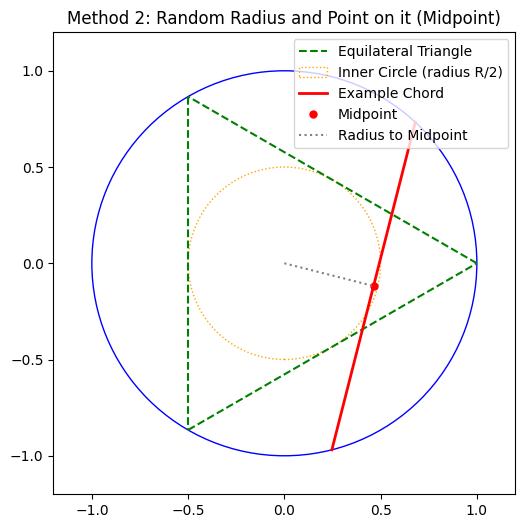

In [7]:
num_simulations = 100000
count_longer_m2 = 0

for _ in range(num_simulations):
    # Choose a random radius by choosing a random angle
    # (this doesn't affect the probability, as all radii are equivalent)
    # Choose a random point on this radius, from the center to the circumference
    # This corresponds to the perpendicular distance 'd' from the center to the chord
    d = np.random.uniform(0, R)

    # The chord length is l = 2 * sqrt(R^2 - d^2)
    # We need l > s, where s = R * sqrt(3)
    # 2 * sqrt(R^2 - d^2) > R * sqrt(3)
    # 4 * (R^2 - d^2) > 3 * R^2
    # 4R^2 - 4d^2 > 3R^2
    # R^2 > 4d^2
    # R > 2d
    # d < R/2

    if d < (R / 2):
        count_longer_m2 += 1

probability_m2 = count_longer_m2 / num_simulations
print(f"Probability (Method 2 - Random Radius and Point): {probability_m2:.4f}")

# Visualization for Method 2
fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), R, color='blue', fill=False)
ax.add_artist(circle)

# Draw an inscribed equilateral triangle
angles_triangle = [0, 2 * np.pi / 3, 4 * np.pi / 3]
for i in range(3):
    x1 = R * np.cos(angles_triangle[i])
    y1 = R * np.sin(angles_triangle[i])
    x2 = R * np.cos(angles_triangle[(i + 1) % 3])
    y2 = R * np.sin(angles_triangle[(i + 1) % 3])
    ax.plot([x1, x2], [y1, y2], color='green', linestyle='--', label='Equilateral Triangle' if i == 0 else '')

# Draw the concentric circle that defines the favorable region
inner_circle = plt.Circle((0, 0), R / 2, color='orange', fill=False, linestyle=':', label='Inner Circle (radius R/2)')
ax.add_artist(inner_circle)

# Illustrate a 'random' chord and its midpoint
# We'll pick a random angle for the radius, and then a random distance along it
random_angle_viz = np.random.uniform(0, 2 * np.pi)
d_viz = np.random.uniform(0, R) # Random distance from center

# Calculate midpoint coordinates
mid_x = d_viz * np.cos(random_angle_viz)
mid_y = d_viz * np.sin(random_angle_viz)

# Calculate chord endpoints
l_viz = 2 * np.sqrt(R**2 - d_viz**2)

# Calculate angle perpendicular to random_angle_viz for chord direction
chord_angle = random_angle_viz + np.pi / 2
x_c2_1 = mid_x + (l_viz / 2) * np.cos(chord_angle)
y_c2_1 = mid_y + (l_viz / 2) * np.sin(chord_angle)
x_c2_2 = mid_x - (l_viz / 2) * np.cos(chord_angle)
y_c2_2 = mid_y - (l_viz / 2) * np.sin(chord_angle)

ax.plot([x_c2_1, x_c2_2], [y_c2_1, y_c2_2], color='red', linewidth=2, label='Example Chord')
ax.plot(mid_x, mid_y, 'ro', markersize=5, label='Midpoint')
ax.plot([0, mid_x], [0, mid_y], color='gray', linestyle=':', label='Radius to Midpoint')

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-R * 1.2, R * 1.2)
ax.set_ylim(-R * 1.2, R * 1.2)
ax.set_title("Method 2: Random Radius and Point on it (Midpoint)")
ax.legend()
plt.show()

### Method 3: Random Midpoint

Choose a random point anywhere within the circle. This point will be the midpoint of the chord.

For the chord length to exceed 's', the midpoint of the chord must fall within a concentric circle of radius $R/2$. This is because any chord with a midpoint outside this inner circle will have a length less than 's'.

Probability (Method 3 - Random Midpoint): 0.2492


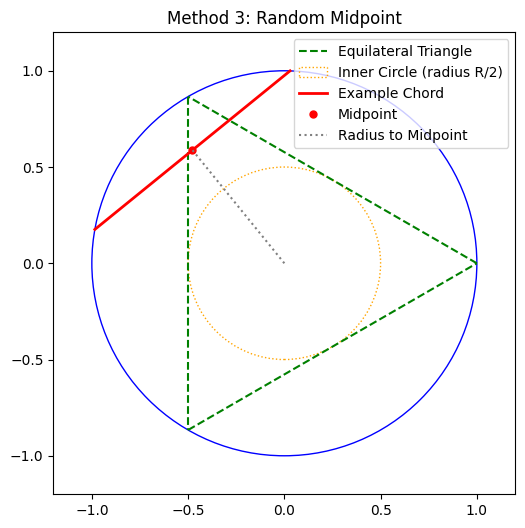

In [8]:
num_simulations = 100000
count_longer_m3 = 0

for _ in range(num_simulations):
    # Choose random coordinates (x, y) within the circle as the midpoint
    # Rejection sampling for points within a circle
    while True:
        x = np.random.uniform(-R, R)
        y = np.random.uniform(-R, R)
        if x**2 + y**2 <= R**2:
            break

    # The distance 'd' from the center to the midpoint
    d = np.sqrt(x**2 + y**2)

    # As in Method 2, the chord is longer than 's' if its midpoint's distance 'd' from the center is < R/2
    if d < (R / 2):
        count_longer_m3 += 1

probability_m3 = count_longer_m3 / num_simulations
print(f"Probability (Method 3 - Random Midpoint): {probability_m3:.4f}")

# Visualization for Method 3
fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), R, color='blue', fill=False)
ax.add_artist(circle)

# Draw an inscribed equilateral triangle
angles_triangle = [0, 2 * np.pi / 3, 4 * np.pi / 3]
for i in range(3):
    x1 = R * np.cos(angles_triangle[i])
    y1 = R * np.sin(angles_triangle[i])
    x2 = R * np.cos(angles_triangle[(i + 1) % 3])
    y2 = R * np.sin(angles_triangle[(i + 1) % 3])
    ax.plot([x1, x2], [y1, y2], color='green', linestyle='--', label='Equilateral Triangle' if i == 0 else '')

# Draw the concentric circle that defines the favorable region
inner_circle = plt.Circle((0, 0), R / 2, color='orange', fill=False, linestyle=':', label='Inner Circle (radius R/2)')
ax.add_artist(inner_circle)

# Illustrate a 'random' chord and its midpoint
# Pick a random midpoint within the circle
while True:
    rand_x = np.random.uniform(-R, R)
    rand_y = np.random.uniform(-R, R)
    if rand_x**2 + rand_y**2 <= R**2:
        break

mid_x_viz = rand_x
mid_y_viz = rand_y
d_viz = np.sqrt(mid_x_viz**2 + mid_y_viz**2)

# Calculate chord endpoints (same as method 2 calculation)
l_viz = 2 * np.sqrt(R**2 - d_viz**2)

# Angle from center to midpoint
angle_to_midpoint = np.arctan2(mid_y_viz, mid_x_viz)
chord_angle = angle_to_midpoint + np.pi / 2 # Chord is perpendicular to radius at midpoint
x_c3_1 = mid_x_viz + (l_viz / 2) * np.cos(chord_angle)
y_c3_1 = mid_y_viz + (l_viz / 2) * np.sin(chord_angle)
x_c3_2 = mid_x_viz - (l_viz / 2) * np.cos(chord_angle)
y_c3_2 = mid_y_viz - (l_viz / 2) * np.sin(chord_angle)

ax.plot([x_c3_1, x_c3_2], [y_c3_1, y_c3_2], color='red', linewidth=2, label='Example Chord')
ax.plot(mid_x_viz, mid_y_viz, 'ro', markersize=5, label='Midpoint')
ax.plot([0, mid_x_viz], [0, mid_y_viz], color='gray', linestyle=':', label='Radius to Midpoint')

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-R * 1.2, R * 1.2)
ax.set_ylim(-R * 1.2, R * 1.2)
ax.set_title("Method 3: Random Midpoint")
ax.legend()
plt.show()

## Summary of Results

| Method                  | Simulated Probability | Theoretical Probability |
| :---------------------- | :-------------------- | :---------------------- |
| 1: Random Endpoints     | ~0.333                | 1/3                     |
| 2: Random Radius & Point| ~0.500                | 1/2                     |
| 3: Random Midpoint      | ~0.250                | 1/4                     |

### Conclusion

As seen from the simulations and graphical interpretations:

*   **Method 1 (Random Endpoints):** The probability is approximately **1/3**. If you fix one endpoint, the second endpoint must fall within a $2\pi/3$ arc (out of $2\pi$ circumference) for the chord to be longer than 's'. So, $(2\pi/3) / (2\pi) = 1/3$.

*   **Method 2 (Random Radius and a Point on It):** The probability is approximately **1/2**. We choose a radius, and then a point on that radius. The chord is longer if its midpoint (the chosen point) is less than $R/2$ from the center. The probability is then $(R/2) / R = 1/2$.

*   **Method 3 (Random Midpoint):** The probability is approximately **1/4**. We choose a random point within the circle as the chord's midpoint. The chord is longer than 's' if its midpoint falls within a concentric circle of radius $R/2$. The ratio of the areas of these circles is $(\pi (R/2)^2) / (\pi R^2) = (R^2/4) / R^2 = 1/4$.

Bertrand's Paradox highlights the importance of precisely defining the sample space when dealing with probability problems. The phrase "at random" is ambiguous, and different interpretations, each seemingly intuitive, lead to different probabilities.